Columns: Index(['order_id', 'distance_km', 'weather', 'traffic_level', 'time_of_day',
       'vehicle_type', 'preparation_time_min', 'courier_experience_yrs',
       'delivery_time_min'],
      dtype='object')

Dependent Variable: delivery_time_min
Predictor Variables: ['order_id', 'distance_km', 'weather', 'traffic_level', 'time_of_day', 'vehicle_type', 'preparation_time_min', 'courier_experience_yrs']

===== SCATTER PLOTS =====


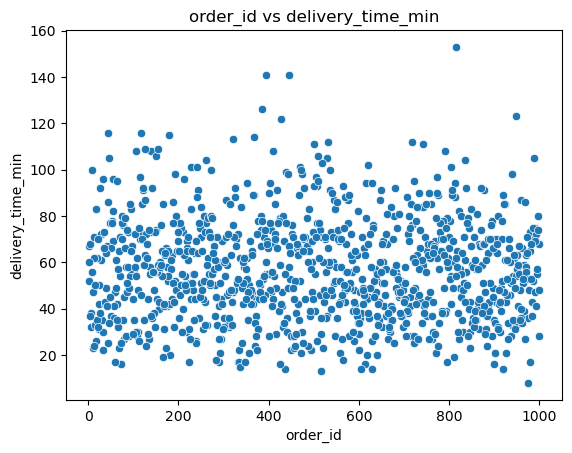

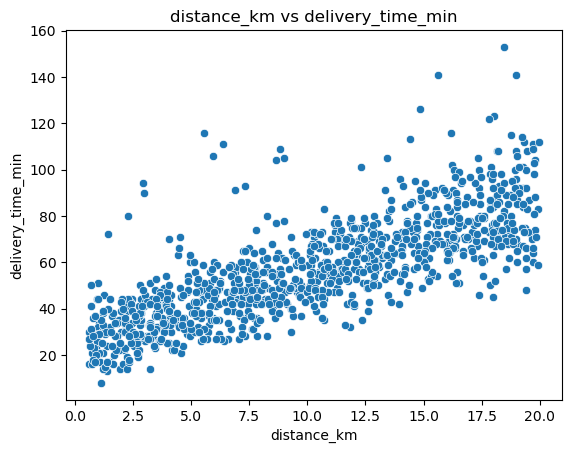

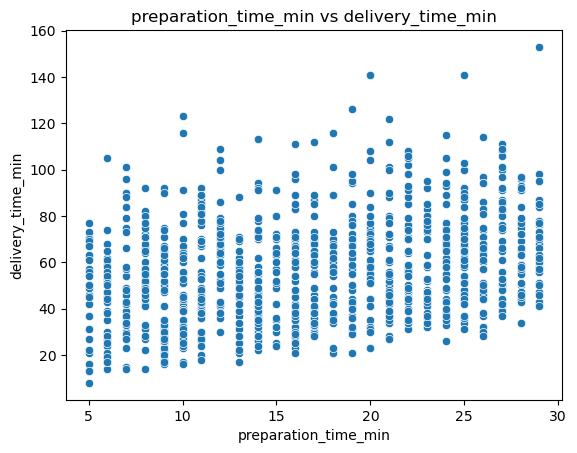

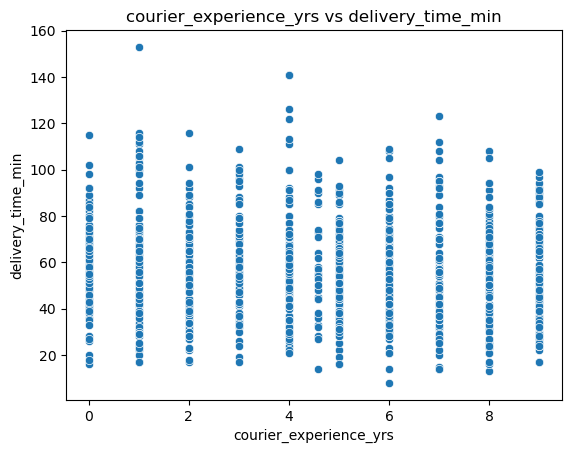

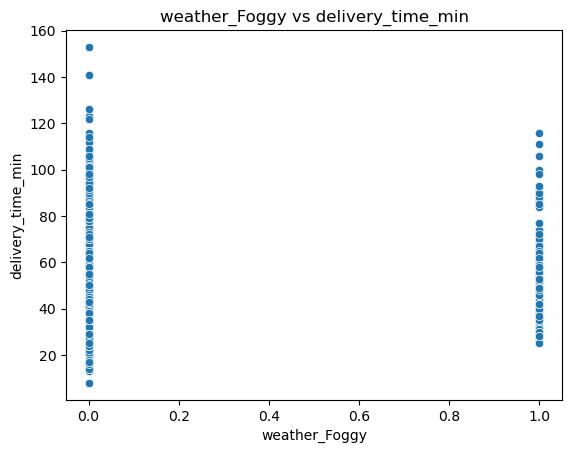

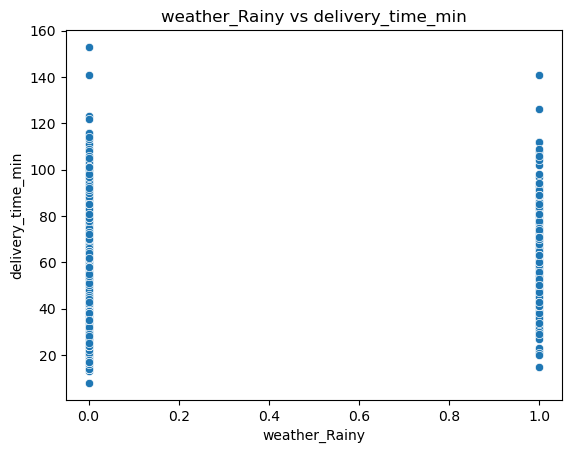

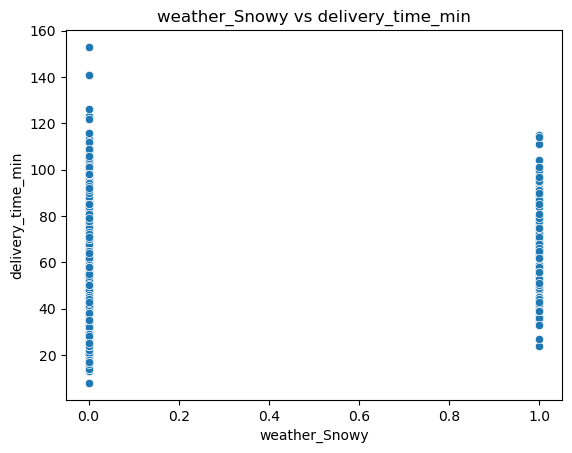

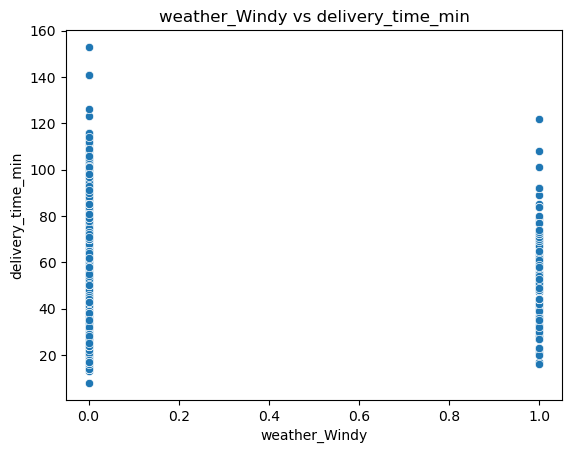

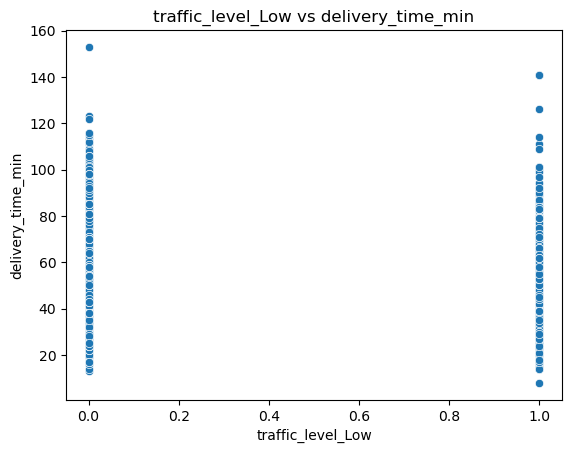

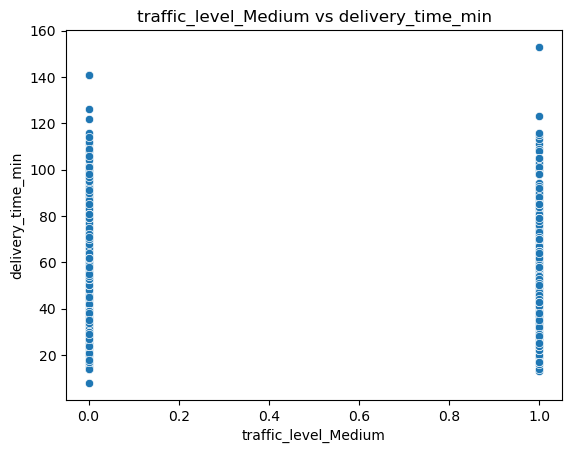

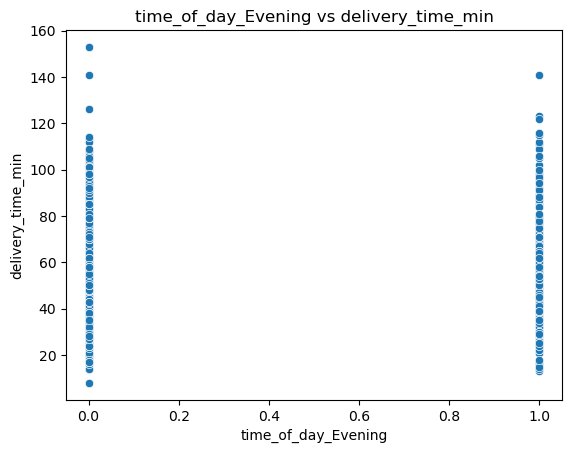

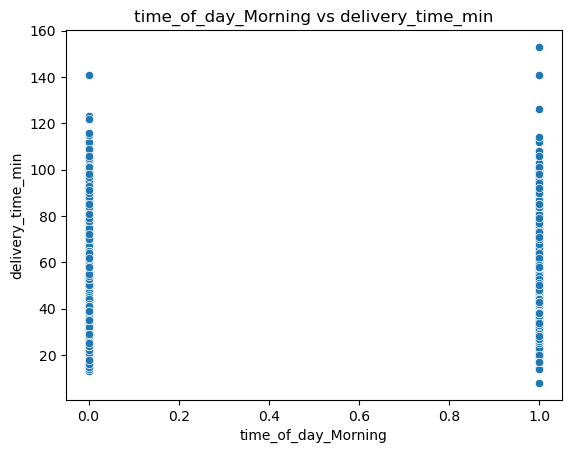

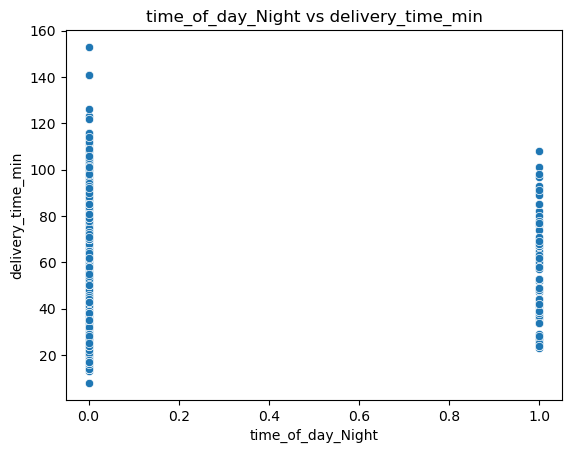

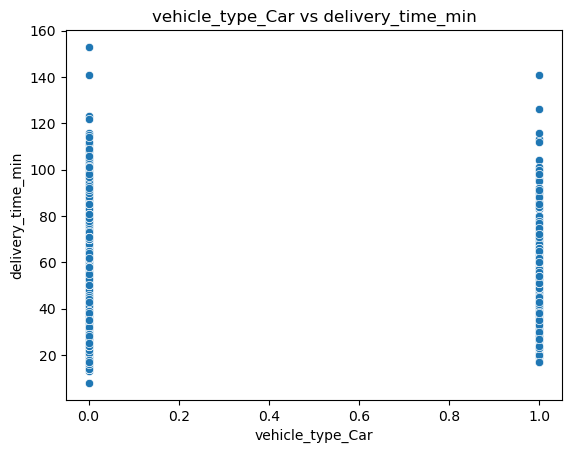

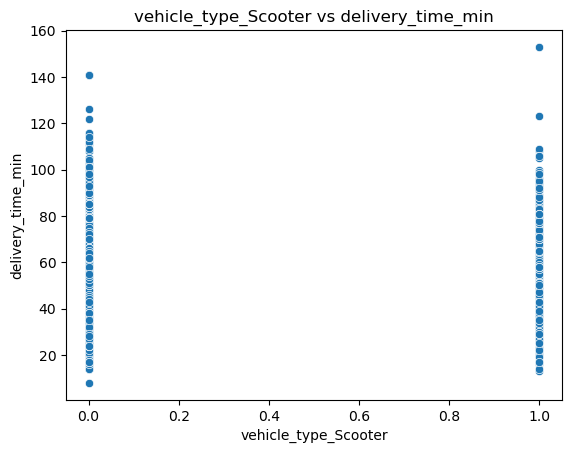


===== SIMPLE LINEAR REGRESSION =====

Feature: order_id
MSE: 449.9739540724508
R2: -0.0038975322099943366

Feature: distance_km
MSE: 158.16196727280166
R2: 0.6471386683659509

Feature: preparation_time_min
MSE: 407.4444922711882
R2: 0.09098623019913477

Feature: courier_experience_yrs
MSE: 447.38207740339493
R2: 0.0018849771292882567

Feature: weather_Foggy
MSE: 449.1004012784823
R2: -0.001948624976179314

Feature: weather_Rainy
MSE: 451.13103225886186
R2: -0.006478988148497455

Feature: weather_Snowy
MSE: 444.68761615784723
R2: 0.007896353944679024

Feature: weather_Windy
MSE: 451.7788594135803
R2: -0.007924298651548645

Feature: traffic_level_Low
MSE: 440.45914768457936
R2: 0.017330120114749104

Feature: traffic_level_Medium
MSE: 450.91506136366746
R2: -0.005997154374003166

Feature: time_of_day_Evening
MSE: 450.4623042886425
R2: -0.004987047664060107

Feature: time_of_day_Morning
MSE: 453.2758770374068
R2: -0.011264163736256272

Feature: time_of_day_Night
MSE: 451.24091492189075
R2

In [2]:
# =========================================================
# LINEAR REGRESSION - Food_Delivery_Times (FIXED VERSION)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# STEP 1: LOAD DATASET
# ---------------------------------------------------------
df = pd.read_csv(r"C:\Users\Subhi Jain\Desktop\dsbda-prac_227\datasets\Food_Delivery_Times.csv")

# ---------------------------------------------------------
# STEP 2: CLEAN COLUMN NAMES
# ---------------------------------------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns:", df.columns)

# ---------------------------------------------------------
# STEP 3: SELECT CORRECT TARGET VARIABLE
# ---------------------------------------------------------
# Always explicitly set (EXAM SAFE)
target = "delivery_time_min"

if target not in df.columns:
    raise Exception("Target column not found!")

print("\nDependent Variable:", target)

# ---------------------------------------------------------
# STEP 4: FEATURES
# ---------------------------------------------------------
features = [col for col in df.columns if col != target]

print("Predictor Variables:", features)

# ---------------------------------------------------------
# STEP 5: HANDLE MISSING VALUES (FIXED WARNING)
# ---------------------------------------------------------
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# ---------------------------------------------------------
# STEP 6: ENCODE CATEGORICAL VARIABLES
# ---------------------------------------------------------
df = pd.get_dummies(df, drop_first=True)

# Update features after encoding
features = [col for col in df.columns if col != target]

# ---------------------------------------------------------
# STEP 7: SCATTER PLOTS (ONLY NUMERIC)
# ---------------------------------------------------------
print("\n===== SCATTER PLOTS =====")

for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.show()

# ---------------------------------------------------------
# STEP 8: TRAIN-TEST SPLIT
# ---------------------------------------------------------
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# STEP 9: SIMPLE LINEAR REGRESSION
# ---------------------------------------------------------
print("\n===== SIMPLE LINEAR REGRESSION =====")

simple_results = {}

for col in X.columns:
    model = LinearRegression()
    model.fit(X_train[[col]], y_train)
    y_pred = model.predict(X_test[[col]])
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    simple_results[col] = mse
    
    print(f"\nFeature: {col}")
    print("MSE:", mse)
    print("R2:", r2)

# Best feature
best_feature = min(simple_results, key=simple_results.get)

print("\nBest Feature:", best_feature)

# ---------------------------------------------------------
# STEP 10: MULTIPLE LINEAR REGRESSION
# ---------------------------------------------------------
print("\n===== MULTIPLE LINEAR REGRESSION =====")

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("MSE (Multiple):", mse_multi)
print("R2 Score:", r2_multi)

# ---------------------------------------------------------
# STEP 11: COMPARISON
# ---------------------------------------------------------
print("\n===== COMPARISON =====")

print("Best Simple MSE:", simple_results[best_feature])
print("Multiple Regression MSE:", mse_multi)

if mse_multi < simple_results[best_feature]:
    print("Multiple Linear Regression performs better.")
else:
    print("Simple Linear Regression performs better.")